In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
VIO<-readRDS(file='/storage/riosugimuralab/alexto/01_MS/F1_VIO.rds')

In [3]:
# View the exact R call string and parameters
VIO@commands$RunPCA@params
VIO@commands$RunUMAP@params

$assay
[1] "RNA"

$npcs
[1] 50

$rev.pca
[1] FALSE

$weight.by.var
[1] TRUE

$verbose
[1] TRUE

$ndims.print
[1] 1 2 3 4 5

$nfeatures.print
[1] 30

$reduction.name
[1] "pca"

$reduction.key
[1] "PC_"

$seed.use
[1] 42

$dims
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30

$reduction
[1] "pca"

$assay
[1] "RNA"

$slot
[1] "data"

$umap.method
[1] "uwot"

$return.model
[1] FALSE

$n.neighbors
[1] 30

$n.components
[1] 2

$metric
[1] "cosine"

$learning.rate
[1] 1

$min.dist
[1] 0.3

$spread
[1] 1

$set.op.mix.ratio
[1] 1

$local.connectivity
[1] 1

$repulsion.strength
[1] 1

$negative.sample.rate
[1] 5

$uwot.sgd
[1] FALSE

$seed.use
[1] 42

$angular.rp.forest
[1] FALSE

$densmap
[1] FALSE

$dens.lambda
[1] 2

$dens.frac
[1] 0.3

$dens.var.shift
[1] 0.1

$verbose
[1] TRUE

$reduction.name
[1] "umap"

In [4]:
# View the summary stats (Min, Median, Max, etc.) for counts and features
summary(VIO@meta.data[, c("nCount_RNA", "nFeature_RNA")])

# Check the maximum mitochondrial percentage left in the dataset
max(VIO$percent.mt) 
# Or if you used the other column shown in your console:
max(VIO$subsets_Mito_percent)

   nCount_RNA      nFeature_RNA  
 Min.   :  2000   Min.   :  518  
 1st Qu.: 12105   1st Qu.: 4149  
 Median : 22914   Median : 5695  
 Mean   : 28570   Mean   : 5576  
 3rd Qu.: 40263   3rd Qu.: 6953  
 Max.   :225605   Max.   :12744  

[1] 14.97036

[1] 14.97036

In [5]:
colnames(VIO@meta.data)

[1] "orig.ident"           "nCount_RNA"           "nFeature_RNA"        
 [4] "subsets_Mito_percent" "subsets_Ribo_percent" "RNA_snn_res.1.2"     
 [7] "percent.mt"           "RNA_snn_res.0.5"      "seurat_clusters"     
[10] "RNA_snn_res.0.3"      "cell_type"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


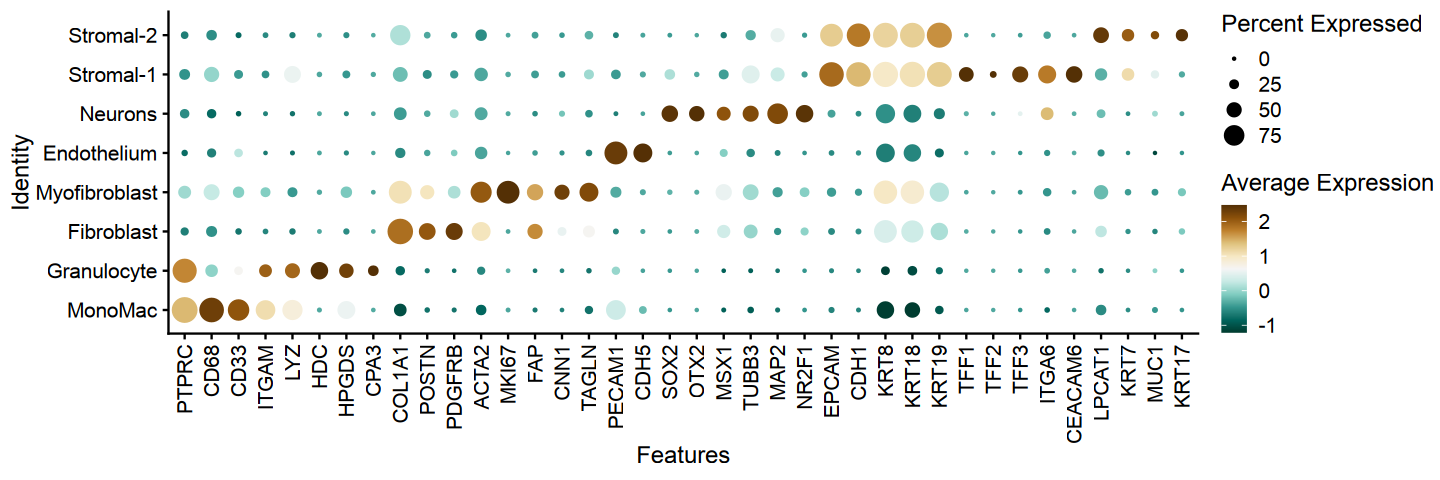

In [6]:
options(repr.plot.width=12, repr.plot.height=4)
DotPlot(VIO,features=c('PTPRC','CD68','CD33','ITGAM','LYZ','HDC','HPGDS','CPA3','COL1A1','POSTN','PDGFRB',
                       'ACTA2','MKI67','FAP','CNN1','TAGLN','PECAM1','CDH5','SOX2','OTX2','MSX1','TUBB3','MAP2',
                       'NR2F1',
                       'EPCAM','CDH1','KRT8','KRT18','KRT19',
                       'TFF1','TFF2','TFF3','ITGA6',
                       'CEACAM6','LPCAT1','KRT7','MUC1','KRT17'
                       ), group.by='cell_type') + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) 

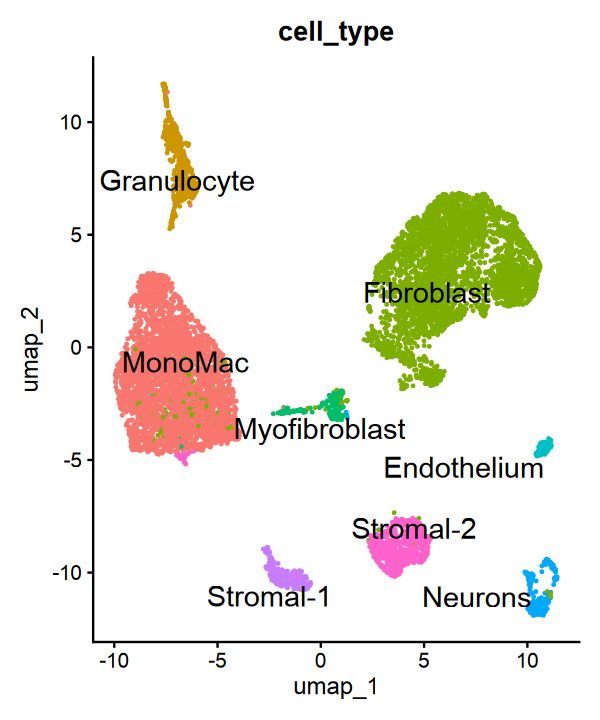

In [7]:
options(repr.plot.width=5, repr.plot.height=6)
DimPlot(VIO, group.by = 'cell_type', label = TRUE, label.size = 6, repel=TRUE) + NoLegend()

In [8]:
# Myeloid subpopulation

In [9]:
mac_subset <- subset(VIO, subset = cell_type == "MonoMac") 

DefaultAssay(mac_subset) <- "RNA"
mac_subset <- NormalizeData(mac_subset, verbose = FALSE) 
mac_subset <- FindVariableFeatures(mac_subset, selection.method = "vst", nfeatures = 2000, verbose = FALSE) # [8]
mac_subset <- RunPCA(mac_subset, npcs = 30, verbose = FALSE) # [8]

mac_subset <- FindNeighbors(mac_subset, dims = 1:30) 
mac_subset <- FindClusters(mac_subset, resolution = 0.3) 
mac_subset <- RunUMAP(mac_subset, dims = 1:30) 

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“Number of dimensions changing from 50 to 30”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3423
Number of edges: 141373

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8352
Number of communities: 6
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
12:13:30 UMAP embedding parameters a = 0.9922 b = 1.112

12:13:30 Read 3423 rows and found 30 numeric columns

12:13:30 Using Annoy for neighbor search, n_neighbors = 30

12:13:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:13:31 Writing NN index file to temp file /tmp/RtmpXFp6J1/file20651a20237bb

12:13:31 Searching Annoy index using 1 thread, search_k = 3000

12:13:32 Annoy recall = 100%

12:13:32 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors 

In [10]:
# 1. Define the identity mapping vector
id_map <- c(
  `0` = "HomoMac",
  `1` = "FABP5+ Mac",
  `2` = "MERTK+ Mac",
  `3` = "S100A8+ Mac",
  `4` = "FOLR2+ Mac",
  `5` = "FCN1+ Mac"
)

# 2. Map from active Idents and explicitly force cell barcodes as vector names
cell_labels <- id_map[as.character(Idents(mac_subset))]
names(cell_labels) <- names(Idents(mac_subset))

# 3. Create the cell_type column from scratch
mac_subset$cell_type <- cell_labels

# 4. Enforce the exact factor levels to match the original DotPlot (bottom to top)
plot_order <- c(
  "HomoMac",
  "S100A8+ Mac",
  "FCN1+ Mac",
  "FOLR2+ Mac",
  "FABP5+ Mac",
  "MERTK+ Mac"
)
mac_subset$cell_type <- factor(mac_subset$cell_type, levels = plot_order)

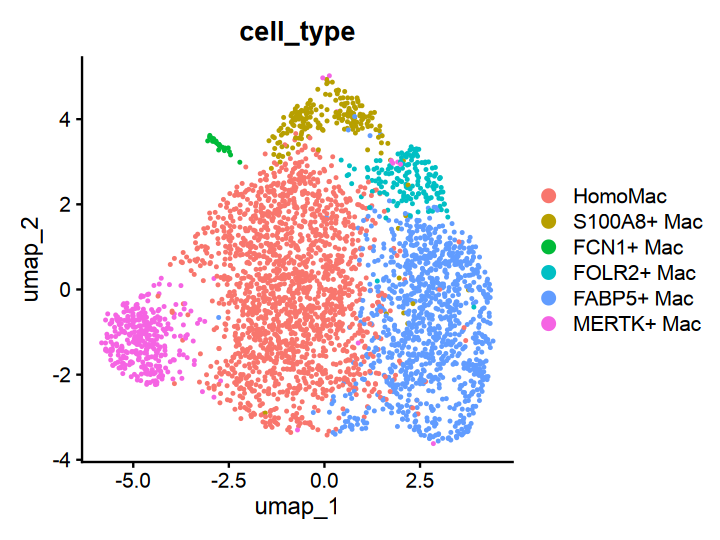

In [11]:
options(repr.plot.height=4.5, repr.plot.width=6)
DimPlot(mac_subset, group.by="cell_type", pt.size=0.2)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


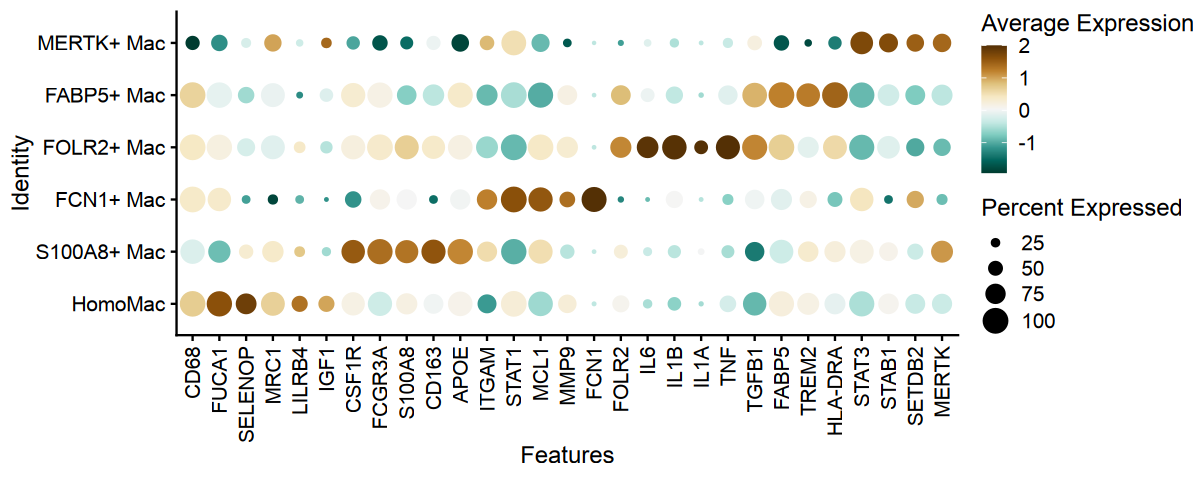

In [12]:
options(repr.plot.height=4, repr.plot.width=10)
DotPlot(mac_subset, group.by="cell_type",features=c(
    "CD68",'FUCA1','SELENOP','MRC1','LILRB4','IGF1',    
    "CSF1R","FCGR3A","S100A8",'CD163','APOE',
   "ITGAM", "STAT1", "MCL1",'MMP9','FCN1',
    "FOLR2","IL6", "IL1B",'IL1A','TNF',
    "TGFB1", "FABP5","TREM2","HLA-DRA",
     "STAT3",'STAB1',"SETDB2","MERTK"), col.min=-2,col.max=2)+ 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) 

In [13]:
# Fibroblast subpopulation

Warning message:
“Number of dimensions changing from 50 to 20”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4051
Number of edges: 130952

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8981
Number of communities: 7
Elapsed time: 0 seconds


12:13:52 UMAP embedding parameters a = 0.9922 b = 1.112

12:13:52 Read 4051 rows and found 20 numeric columns

12:13:52 Using Annoy for neighbor search, n_neighbors = 30

12:13:52 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:13:53 Writing NN index file to temp file /tmp/RtmpXFp6J1/file20651a3c8a4374

12:13:53 Searching Annoy index using 1 thread, search_k = 3000

12:13:54 Annoy recall = 100%

12:13:54 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:13:55 Initializing from normalized Laplacian + noise (using RSpectra)

12:13:55 Commencing optimization for 500 epochs, with 157986 positive edges

12:13:55 Using rng type: pcg

12:14:01 Optimization finished



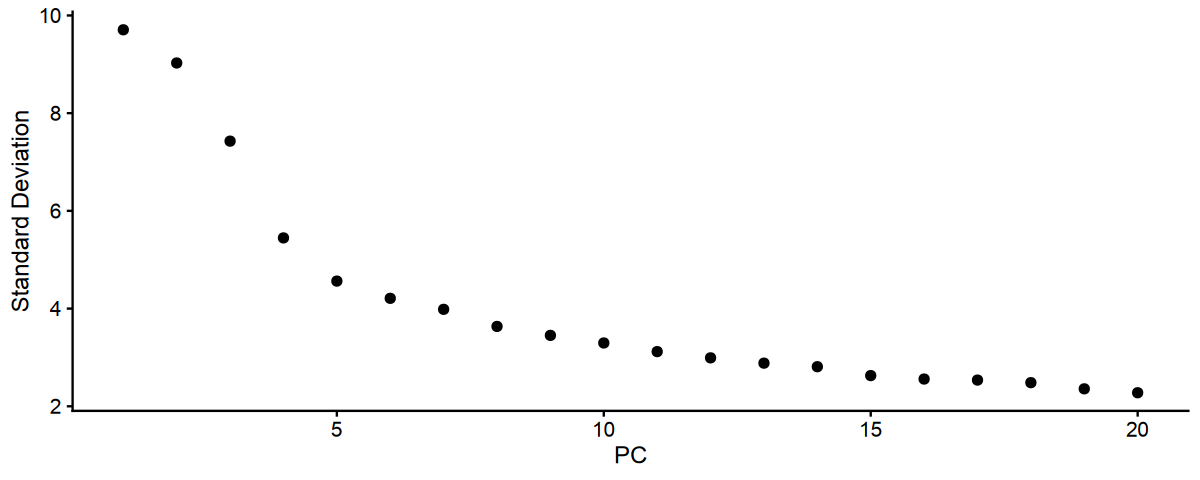

In [14]:
fib_subset <- subset(VIO, subset = cell_type %in% c("Fibroblast", "Myofibroblast")) 

DefaultAssay(fib_subset) <- "RNA"
fib_subset <- NormalizeData(fib_subset, verbose = FALSE) 
fib_subset <- FindVariableFeatures(fib_subset, selection.method = "vst", nfeatures = 2000, verbose = FALSE) # [8]
fib_subset <- RunPCA(fib_subset, npcs = 20, verbose = FALSE) # [8]

# (Optional) Visualize PCA elbow plot to choose dimensions
ElbowPlot(fib_subset)

fib_subset <- FindNeighbors(fib_subset, dims = 1:20) 
fib_subset <- FindClusters(fib_subset, resolution = 0.2) 
fib_subset <- RunUMAP(fib_subset, dims = 1:20) 

In [15]:
Idents(fib_subset) <- "seurat_clusters"

fib_subset <- RenameIdents(
  fib_subset,
  `5` = "Macrophages",
  `0` = "Neuronal-like",
  `3` = "Epithelium",          # adjust if a different cluster is Epithelium
  `1` = "Myofibroblasts",
  `2` = "POSTN+ Fibroblast",
  `4` = "MKI67+ Fibroblast",   # adjust if needed
  `6` = "PDGFRB+ Fibroblast"
)
Idents(fib_subset) <- factor(
  Idents(fib_subset),
  levels = c(
    "Macrophages",
    "Neuronal-like",
    "Epithelium",
    "Myofibroblasts",
    "POSTN+ Fibroblast",
    "MKI67+ Fibroblast",
    "PDGFRB+ Fibroblast"
  )
)

levels(Idents(fib_subset))
# [1] "Macrophages" "Neuronal-like" "Epithelium" "Myofibroblasts"
#     "POSTN+ Fibroblast" "MKI67+ Fibroblast" "PDGFRB+ Fibroblast"


[1] "Macrophages"        "Neuronal-like"      "Epithelium"        
[4] "Myofibroblasts"     "POSTN+ Fibroblast"  "MKI67+ Fibroblast" 
[7] "PDGFRB+ Fibroblast"

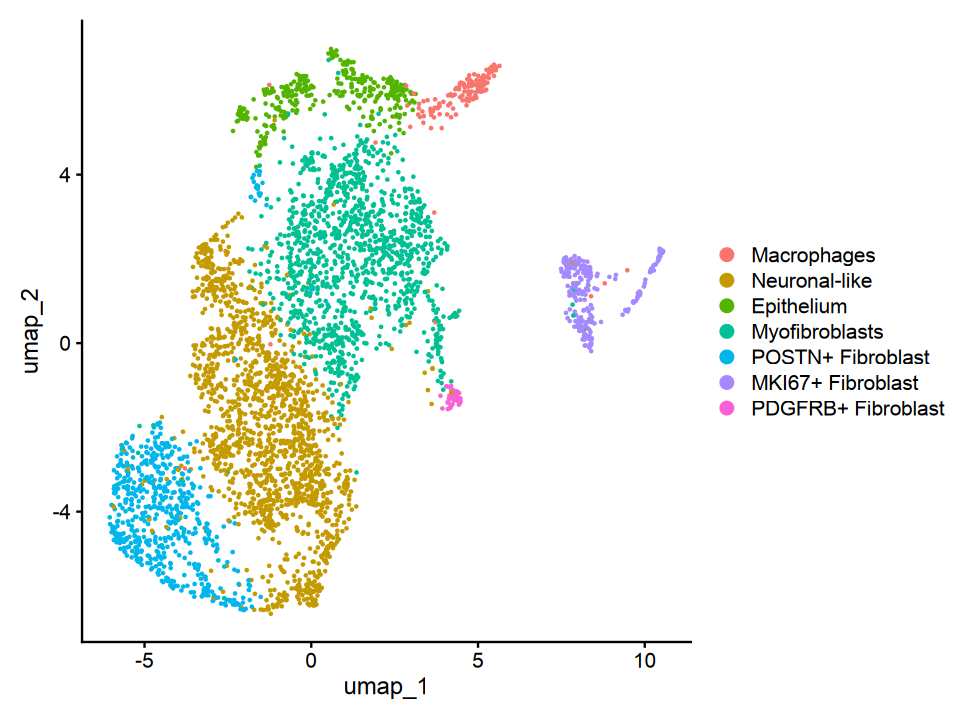

In [16]:
options(repr.plot.height=6, repr.plot.width=8)
DimPlot(fib_subset, pt.size=0.1)

In [17]:
# Subset the Endothelium population
VIO_endo <- subset(VIO, subset = cell_type == "Endothelium")

Centering and scaling data matrix

PC_ 1 
Positive:  AC008014.1, AL365295.1, NEAT1, PRKD1, PLCL1, ITPR2, MIR99AHG, TNIK, PARD3B, TG 
	   CACHD1, ANK2, PTPRG, NRG2, DLEU1, ATXN1, AC011287.2, MECOM, SYT14, AC113414.1 
	   ITSN1, PPP2R3A, BBS9, STARD13, ST6GALNAC3, DGKH, LINC02147, FLRT2, AP001636.3, RALGAPA2 
Negative:  TPT1, RPL41, RPS8, RPL18, RPLP1, RPL13, RPL30, RPS27A, RPS12, RPL15 
	   RPS15A, RPS14, RPS18, RPL19, EEF1A1, RPS3A, RPL26, RPS4X, GAPDH, RPL5 
	   RPS23, RPL6, RPL29, RPL18A, RPL28, RPS24, RPL17, RPL3, RPL13A, RPS9 
PC_ 2 
Positive:  MEF2C, FLT1, A2M, AC114757.1, HLX, SPRY1, HMGA2-AS1, AC015631.1, RP1, ANKS1B 
	   CCSER1, ADAMTS9-AS2, IQCJ-SCHIP1, AC080132.1, AL589693.1, ADGRV1, MYO1B, UBE2J1, IL1RAPL2, EGFL7 
	   SOX5, TM4SF18, LNCAROD, RAB3C, AC004470.1, LINC01829, ST8SIA4, KHDRBS2, BBOX1-AS1, RUNX1 
Negative:  PRICKLE1, AC092353.2, EFNA5, PKP2, IL33, SOX6, PALMD, MIR100HG, PID1, PDE3A 
	   MIR99AHG, SLIT3, PDZRN3, PDGFRA, NRG3, TNIK, SDC2, FREM1, HPSE2, PARD3B 
	   PG

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 119
Number of edges: 4889

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.3423
Number of communities: 2
Elapsed time: 0 seconds


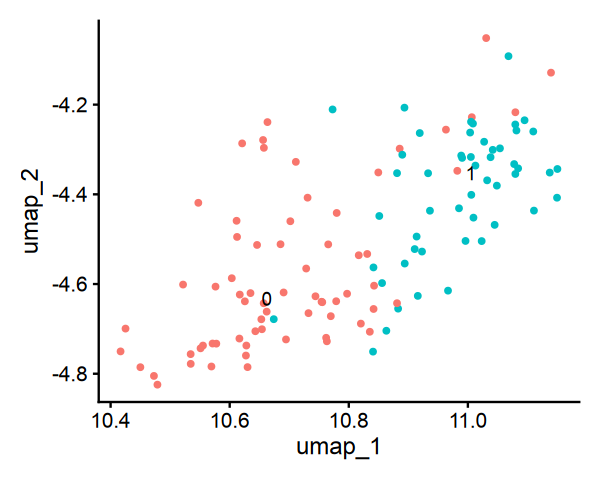

In [18]:
# 1. Standard processing for the subset
VIO_endo <- NormalizeData(VIO_endo)
VIO_endo <- FindVariableFeatures(VIO_endo)
VIO_endo <- ScaleData(VIO_endo)
VIO_endo <- RunPCA(VIO_endo)

# 2. Find neighbors and clusters
# Adjust 'resolution' to get exactly two clusters; 0.1 or 0.2 is a good starting point
VIO_endo <- FindNeighbors(VIO_endo, dims = 1:50)
VIO_endo <- FindClusters(VIO_endo, resolution = 1)

# 3. Visualize the results
options(repr.plot.width=5, repr.plot.height=4)
DimPlot(VIO_endo, label = TRUE) + NoLegend()

In [19]:
# Rename the identities
VIO_endo <- RenameIdents(VIO_endo, `0` = "EC-1", `1` = "EC-2")

# Save the new identities into a metadata column
VIO_endo$cell_type_labeled <- Idents(VIO_endo)

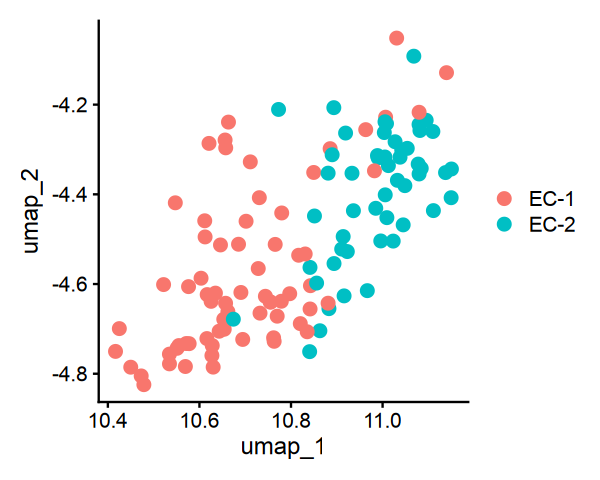

In [20]:
# 3. Visualize the results
options(repr.plot.width = 5, repr.plot.height = 4)
DimPlot(VIO_endo, pt.size = 3)

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


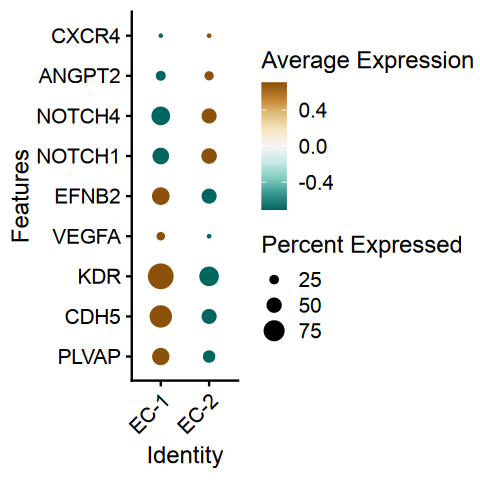

In [21]:
features <- c("PLVAP", "CDH5", "KDR", "VEGFA", "EFNB2", "NOTCH1", "NOTCH4", "ANGPT2", "CXCR4")

options(repr.plot.width = 4, repr.plot.height = 4)
DotPlot(VIO_endo, features = features) + 
  coord_flip() + 
  scale_colour_gradientn(colours = rev(brewer.pal(n = 9, name = "BrBG"))) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))